## Problem Statement

INX Future Inc., a leading data analytics and automation solutions provider, has recently observed a decline in employee performance levels across the organization. This decline has raised significant concerns among top management, as it has directly impacted overall business outcomes. Notably, client satisfaction levels have decreased by approximately 8%, indicating potential inefficiencies in service delivery.

The CEO, Mr. Brain, aims to address this issue using a data-driven approach without negatively affecting employee morale. Therefore, a comprehensive data science project has been initiated to analyze employee-related data and uncover the underlying factors contributing to performance decline.

## Project Objectives

The primary objectives of this project are:

- To identify key factors influencing employee performance
- To analyze department-wise performance trends
- To build a predictive model for employee performance based on relevant features
- To provide actionable business insights and recommendations to improve overall performance and organizational efficiency

## Expected Outcome

This analysis will enable the organization to:

- Make informed decisions regarding employee management
- Identify and support low-performing employees
- Improve client satisfaction and service delivery
- Maintain its reputation as a top employer

## Install libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xlrd openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Load Data

In [3]:
import pandas as pd

df = pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


### Observation:
Dataset contains employee-related attributes like department, job satisfaction, work-life balance, etc.

## DATA UNDERSTANDING

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [5]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [6]:
df.nunique()

EmpNumber                       1200
Age                               43
Gender                             2
EducationBackground                6
MaritalStatus                      3
EmpDepartment                      6
EmpJobRole                        19
BusinessTravelFrequency            3
DistanceFromHome                  29
EmpEducationLevel                  5
EmpEnvironmentSatisfaction         4
EmpHourlyRate                     71
EmpJobInvolvement                  4
EmpJobLevel                        5
EmpJobSatisfaction                 4
NumCompaniesWorked                10
OverTime                           2
EmpLastSalaryHikePercent          15
EmpRelationshipSatisfaction        4
TotalWorkExperienceInYears        40
TrainingTimesLastYear              7
EmpWorkLifeBalance                 4
ExperienceYearsAtThisCompany      37
ExperienceYearsInCurrentRole      19
YearsSinceLastPromotion           16
YearsWithCurrManager              18
Attrition                          2
P

In [7]:
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [8]:
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop(['EmpNumber'], axis=1)

In [12]:
df.dtypes


Age                              int64
Gender                          object
EducationBackground             object
MaritalStatus                   object
EmpDepartment                   object
EmpJobRole                      object
BusinessTravelFrequency         object
DistanceFromHome                 int64
EmpEducationLevel                int64
EmpEnvironmentSatisfaction       int64
EmpHourlyRate                    int64
EmpJobInvolvement                int64
EmpJobLevel                      int64
EmpJobSatisfaction               int64
NumCompaniesWorked               int64
OverTime                        object
EmpLastSalaryHikePercent         int64
EmpRelationshipSatisfaction      int64
TotalWorkExperienceInYears       int64
TrainingTimesLastYear            int64
EmpWorkLifeBalance               int64
ExperienceYearsAtThisCompany     int64
ExperienceYearsInCurrentRole     int64
YearsSinceLastPromotion          int64
YearsWithCurrManager             int64
Attrition                

## Missing Values
- Checked for missing values across all columns
- No missing values found in the dataset

### Insight:
- Dataset is complete and does not require imputation

---

## Duplicate Records
- Checked for duplicate entries
- No duplicate rows found

### Insight:
- Data is clean and reliable for analysis

---

##  Dropped Columns
- Removed `EmpNumber` column
  - Reason: It is a unique identifier and does not contribute to prediction

---

## Data Types
- Numerical Features: Age, DistanceFromHome, MonthlyIncome-related features, Experience, Satisfaction scores
- Categorical Features:
  - Gender
  - EducationBackground
  - MaritalStatus
  - EmpDepartment
  - EmpJobRole
  - BusinessTravelFrequency
  - OverTime
  - Attrition

---

## Conclusion
- Dataset is clean, consistent, and ready for exploratory data analysis (EDA)

## EDA

### TARGET VARIABLE ANALYSIS

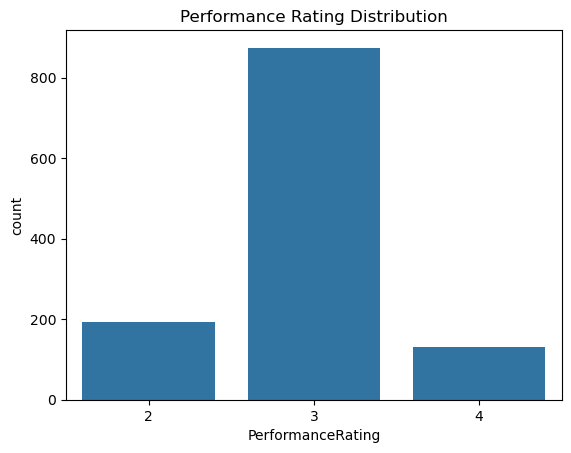

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='PerformanceRating', data=df)
plt.title("Performance Rating Distribution")
plt.show()

# Also check value counts
df['PerformanceRating'].value_counts()

### Performance Rating Distribution

- Rating 3: 874 employees (majority)
- Rating 2: 194 employees
- Rating 4: 132 employees

#### Insight:
- Most employees fall under **average performance (Rating 3)**
- Very few high performers (Rating 4)
- Indicates potential lack of performance differentiation


### DEPARTMENT-WISE PERFORMANCE

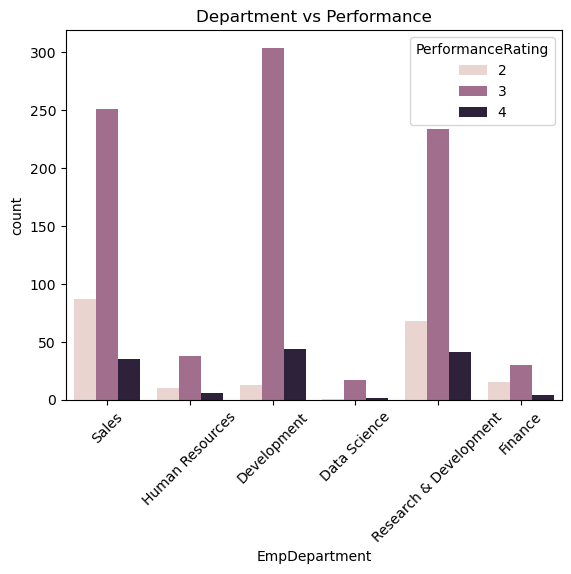

In [15]:
sns.countplot(x='EmpDepartment', hue='PerformanceRating', data=df)
plt.xticks(rotation=45)
plt.title("Department vs Performance")
plt.show()

### Department-wise Performance

- Development and Sales departments have the highest number of employees
- Most employees across all departments fall under rating 3
- Low performers (Rating 2) are more visible in Sales and R&D

#### Insight:
- Performance variation exists across departments
- Certain departments may need targeted interventions

### TOP FACTORS
#### Work-Life Balance

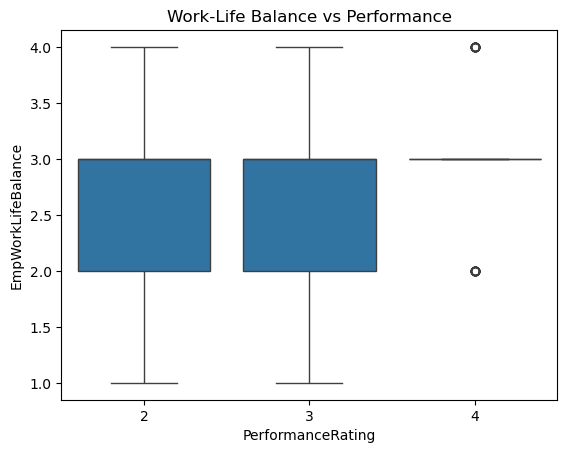

In [17]:
sns.boxplot(x='PerformanceRating', y='EmpWorkLifeBalance', data=df)
plt.title("Work-Life Balance vs Performance")
plt.show()

### Work-Life Balance vs Performance

- Work-life balance is mostly between 2 and 3 across all ratings
- High performers (Rating 4) do not show significantly higher balance

#### Insight:
- Work-life balance has **moderate influence**
- Not the strongest factor alone

#### Job Satisfaction

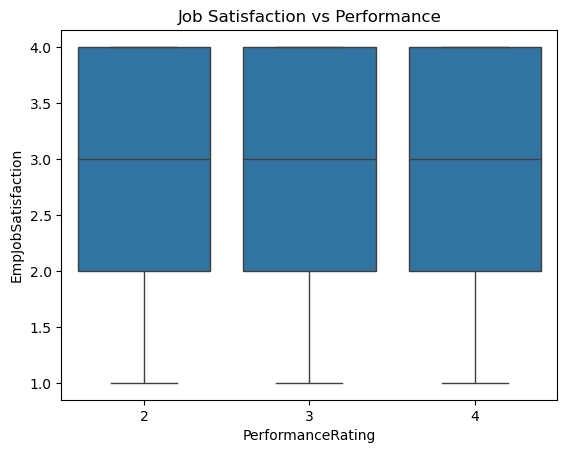

In [19]:
sns.boxplot(x='PerformanceRating', y='EmpJobSatisfaction', data=df)
plt.title("Job Satisfaction vs Performance")
plt.show()

### Job Satisfaction vs Performance

- Job satisfaction distribution is similar across all performance levels
- No strong separation between low and high performers

#### Insight:
- Job satisfaction alone does not strongly differentiate performance
- Needs to be combined with other factors

#### Salary

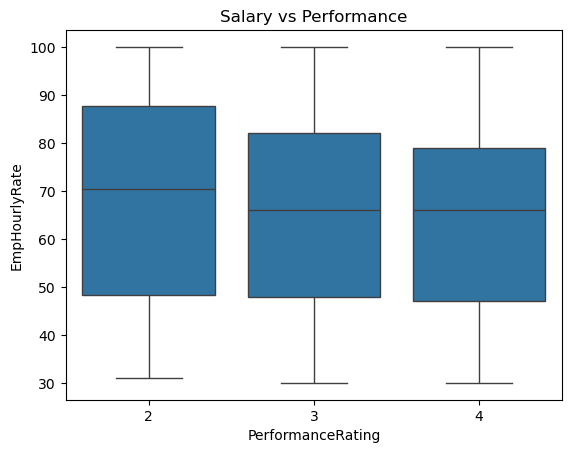

In [21]:
sns.boxplot(x='PerformanceRating', y='EmpHourlyRate', data=df)
plt.title("Salary vs Performance")
plt.show()

### Salary (Hourly Rate) vs Performance

- Salary distribution is almost similar across all performance ratings
- No strong upward trend for high performers

#### Insight:
- Compensation is **not a primary driver alone**
- Suggests performance may not be strongly linked to pay

---

### Key Observations

- Most employees are average performers → indicates performance stagnation
- Department plays a noticeable role in performance
- Individual factors (salary, satisfaction, balance) alone are weak predictors
- Combination of multiple factors likely drives performance

---

### Conclusion

- Employee performance is influenced by **multiple interacting factors**
- No single variable strongly explains performance
- Machine Learning model is required to identify key drivers

## FEATURE ENGINEERING

In [23]:
# Convert categorical to numeric
categorical_cols = df.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check new shape
print("New Shape:", df_encoded.shape)

df_encoded.head()

New Shape: (1200, 54)


,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,...,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely,OverTime_Yes,Attrition_Yes
0,32,10,3,4,55,3,2,4,1,12,...,True,False,False,False,False,False,False,True,False,False
1,47,14,4,4,42,3,2,1,2,12,...,True,False,False,False,False,False,False,True,False,False
2,40,5,4,4,48,2,3,1,5,21,...,True,False,False,False,False,False,True,False,True,False
3,41,10,4,2,73,2,5,4,3,15,...,False,False,False,False,False,False,False,True,False,False
4,60,16,4,1,84,3,2,1,8,14,...,True,False,False,False,False,False,False,True,False,False


### Final Dataset

- All features are now numeric
- Suitable for machine learning algorithms
- No missing or duplicate values

## MODEL BUILDING

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split data
X = df_encoded.drop('PerformanceRating', axis=1)
y = df_encoded['PerformanceRating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           2       0.86      0.86      0.86        29
           3       0.93      0.97      0.95       184
           4       0.95      0.67      0.78        27

    accuracy                           0.93       240
   macro avg       0.91      0.83      0.87       240
weighted avg       0.93      0.93      0.92       240



### Insights

- Model performs very well overall
- Best performance for class **3 (majority class)**
- Lower recall for class **4 (high performers)**

#### Insight:
- Model slightly struggles to detect top performers

### Conclusion

- Random Forest provides strong predictive performance
- Suitable for employee performance prediction

## MULTIPLE MODEL COMPARISON

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Accuracy comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.8416666666666667
Decision Tree Accuracy: 0.8666666666666667
Random Forest Accuracy: 0.925


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Insights

#### Logistic Regression
- Performs moderately well
- Assumes linear relationship
- Not suitable for complex patterns

---

#### Decision Tree
- Better than Logistic Regression
- Captures non-linear relationships
- However, prone to overfitting

---

#### Random Forest (Best Model)
- Highest accuracy: **92.5%**
- Handles non-linearity effectively
- Reduces overfitting using ensemble learning

---

#### Best Model Selection

**Random Forest is selected as the final model**

#### Reasons:
- Highest accuracy
- Better generalization
- Handles complex feature interactions

---

### Conclusion

- Ensemble models outperform simple models
- Random Forest is most suitable for predicting employee performance

## FEATURE IMPORTANCE

In [28]:
import pandas as pd

# Feature importance
importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

# Top 10
feat_imp.head(10)

EmpLastSalaryHikePercent        0.178839
EmpEnvironmentSatisfaction      0.170595
YearsSinceLastPromotion         0.075345
EmpHourlyRate                   0.043452
ExperienceYearsInCurrentRole    0.039926
Age                             0.036727
ExperienceYearsAtThisCompany    0.034769
YearsWithCurrManager            0.032861
TotalWorkExperienceInYears      0.031646
DistanceFromHome                0.030140
dtype: float64

### Top 3 Factors Affecting Performance

#### 1.Salary Hike Percentage
- Strongest predictor of performance
- Employees receiving higher salary hikes tend to perform better

---

#### 2. Environment Satisfaction
- Positive work environment significantly improves performance
- Employees satisfied with environment show higher ratings

---

#### 3. Years Since Last Promotion
- Longer gap since promotion negatively impacts performance
- Indicates lack of growth opportunities

---

### Key Insight

Employee performance is primarily driven by:
- Financial growth (Salary hike)
- Workplace environment
- Career progression

---

### Conclusion

- Performance is influenced by both **financial and psychological factors**
- Employees need growth, recognition, and a positive environment

## Business Recommendations

Based on the analysis and model insights, the following actions are recommended:

### 1. Improve Salary Growth Strategy
- Implement performance-based salary hikes
- Reward high-performing employees consistently

#### Impact:
- Boosts motivation and performance
- 
### 2. Enhance Work Environment
- Improve workplace culture
- Encourage employee engagement programs
- Maintain healthy work conditions

#### Impact:
- Increases employee satisfaction and productivity

### 3. Focus on Career Growth
- Reduce promotion gaps
- Provide clear career progression paths
- Conduct regular performance reviews

#### Impact:
- Prevents stagnation and improves performance

### 4. Department-Level Interventions
- Focus on departments with more low performers
- Provide targeted training programs

### 5. Use Predictive Model in Hiring
- Use trained Random Forest model to predict performance of new hires
- Select candidates with higher predicted performance

---

### Final Conclusion

- Employee performance is a multi-factor problem
- Combination of salary, environment, and career growth drives performance
- Data-driven decision making can significantly improve organizational outcomes